# **LABORATORIO 5: MODELOS DE APRENDIZAJE AUTOMÁTICO**

Objetivo: Crear un modelo de k-NN que haga predicciones de clasificación de células mamarias benignas o cancerígenas.

## **PARTE A: Preparación de los datos**

In [1]:
# Importación de librerías
import pandas as pd # Trabajar con datos estructurados
from IPython.display import display, HTML # Visualización de objetos
import matplotlib.pyplot as plt # Visualización de gráficos
import seaborn as sns # Visualización de gráficos

In [2]:
# Lectura de la data
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/breast-cancer-wisconsin/breast-cancer-wisconsin.data"
data = pd.read_csv(url, header = None)
data.head()

,0,1,2,3,4,5,6,7,8,9,10
0,1000025,5,1,1,1,2,1,3,1,1,2
1,1002945,5,4,4,5,7,10,3,2,1,2
2,1015425,3,1,1,1,2,2,3,1,1,2
3,1016277,6,8,8,1,3,4,3,7,1,2
4,1017023,4,1,1,3,2,1,3,1,1,2


In [3]:
# Renombramiento de las columnas del dataframe
data.columns = ["id", "clump_thickness", "size_uniformity", "shape_uniformity", "marginal_adhesion", "epithelial_size",
               "bare_nucleoli", "bland_chromatin", "normal_nucleoli", "mitoses", "class"]
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 699 entries, 0 to 698
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   id                 699 non-null    int64 
 1   clump_thickness    699 non-null    int64 
 2   size_uniformity    699 non-null    int64 
 3   shape_uniformity   699 non-null    int64 
 4   marginal_adhesion  699 non-null    int64 
 5   epithelial_size    699 non-null    int64 
 6   bare_nucleoli      699 non-null    object
 7   bland_chromatin    699 non-null    int64 
 8   normal_nucleoli    699 non-null    int64 
 9   mitoses            699 non-null    int64 
 10  class              699 non-null    int64 
dtypes: int64(10), object(1)
memory usage: 60.2+ KB


In [4]:
# Se transforman los datos para separar el dataframe en variables numéricas y no numéricas

# Variable 'bare_nucleoli':
# Se reemplazan los valores nulos (?) por la mediana
data['bare_nucleoli'] = data['bare_nucleoli'].replace("?",pd.NA)
mediana = data['bare_nucleoli'].median()
data['bare_nucleoli'] = data['bare_nucleoli'].fillna(mediana)

# Se convierte la variable a tipo entero
data['bare_nucleoli'] = data['bare_nucleoli'].astype(int)

# Variable 'class':
# Se modifican las categorías '2' y '4' por valores binarios: '0' corresponde a benigno y '1' a maligno
data['class'] = data['class'].apply(lambda x: 0 if x == 2 else 1)

# Se convierte la variable a tipo categórica
data['class'] = data['class'].astype('category')

# Variable 'id':
# Se convierte la variable a tipo cadena
data['id'] = data['id'].astype(str)

In [5]:
# Se separa el dataframe en variables numéricas y no numéricas
data_numeric = data.select_dtypes(include = 'number')
data_no_numeric = data.select_dtypes(exclude = 'number')

# Se muestra el dataframe de variables numéricas
display(HTML("<h4>DataFrame de variables numéricas</h4>"))
display(data_numeric.head())

# Se muestra el dataframe de variables no numéricas
display(HTML("<h4>DataFrame de variables no numéricas</h4>"))
display(data_no_numeric.head())

,clump_thickness,size_uniformity,shape_uniformity,marginal_adhesion,epithelial_size,bare_nucleoli,bland_chromatin,normal_nucleoli,mitoses
0,5,1,1,1,2,1,3,1,1
1,5,4,4,5,7,10,3,2,1
2,3,1,1,1,2,2,3,1,1
3,6,8,8,1,3,4,3,7,1
4,4,1,1,3,2,1,3,1,1


,id,class
0,1000025,0
1,1002945,0
2,1015425,0
3,1016277,0
4,1017023,0


In [6]:
# Se calculan los estadísticos descriptivos de las variables numéricas
data_numeric.describe()

,clump_thickness,size_uniformity,shape_uniformity,marginal_adhesion,epithelial_size,bare_nucleoli,bland_chromatin,normal_nucleoli,mitoses
count,699.000000,699.000000,699.000000,699.000000,699.000000,699.000000,699.000000,699.000000,699.000000
mean,4.417740,3.134478,3.207439,2.806867,3.216023,3.486409,3.437768,2.866953,1.589413
std,2.815741,3.051459,2.971913,2.855379,2.214300,3.621929,2.438364,3.053634,1.715078
min,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
25%,2.000000,1.000000,1.000000,1.000000,2.000000,1.000000,2.000000,1.000000,1.000000
50%,4.000000,1.000000,1.000000,1.000000,2.000000,1.000000,3.000000,1.000000,1.000000
75%,6.000000,5.000000,5.000000,4.000000,4.000000,5.000000,5.000000,4.000000,1.000000
max,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000


,clump_thickness,size_uniformity,shape_uniformity,marginal_adhesion,epithelial_size,bare_nucleoli,bland_chromatin,normal_nucleoli,mitoses
clump_thickness,1.000000,0.644913,0.654589,0.486356,0.521816,0.590008,0.558428,0.535835,0.350034
size_uniformity,0.644913,1.000000,0.906882,0.705582,0.751799,0.686673,0.755721,0.722865,0.458693
shape_uniformity,0.654589,0.906882,1.000000,0.683079,0.719668,0.707474,0.735948,0.719446,0.438911
marginal_adhesion,0.486356,0.705582,0.683079,1.000000,0.599599,0.666971,0.666715,0.603352,0.417633
epithelial_size,0.521816,0.751799,0.719668,0.599599,1.000000,0.583701,0.616102,0.628881,0.479101
bare_nucleoli,0.590008,0.686673,0.707474,0.666971,0.583701,1.000000,0.674215,0.574778,0.342397
bland_chromatin,0.558428,0.755721,0.735948,0.666715,0.616102,0.674215,1.000000,0.665878,0.344169
normal_nucleoli,0.535835,0.722865,0.719446,0.603352,0.628881,0.574778,0.665878,1.000000,0.428336
mitoses,0.350034,0.458693,0.438911,0.417633,0.479101,0.342397,0.344169,0.428336,1.000000


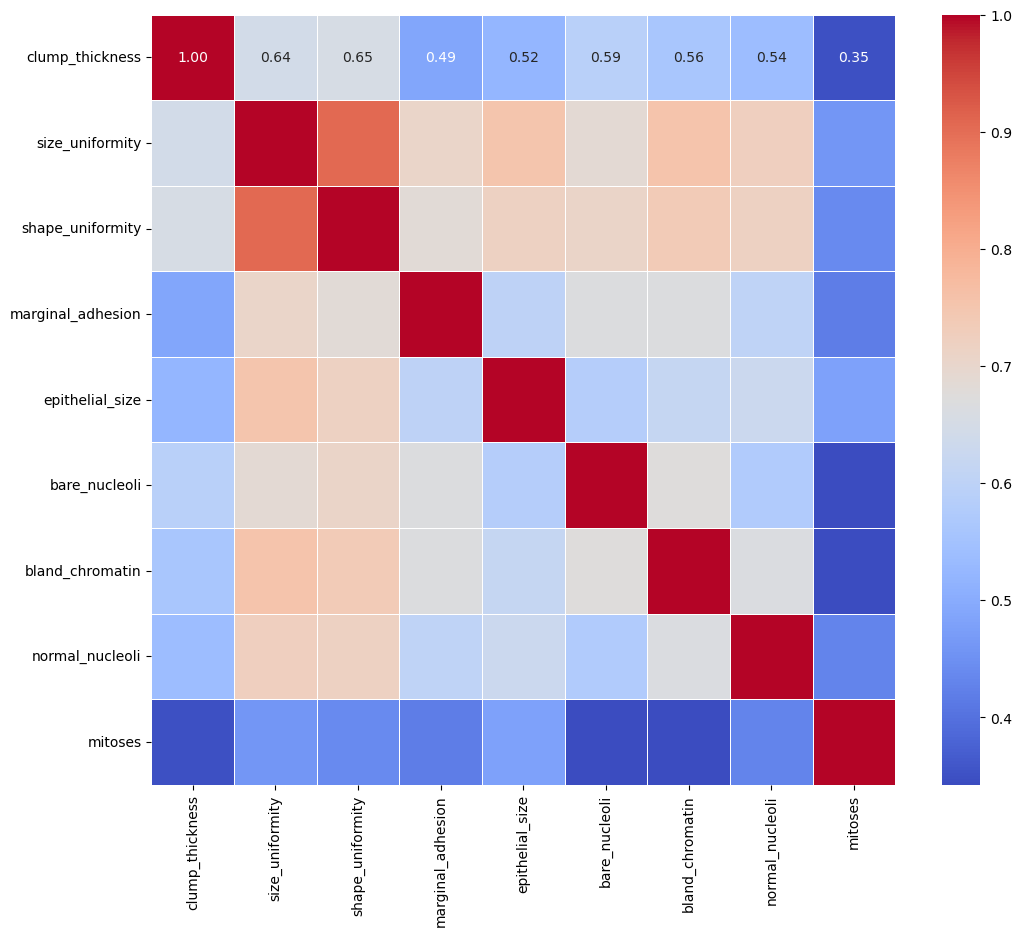

In [7]:
# Se determina la matriz de correlación entre las variables numéricas
matriz_cor = data_numeric.corr()

# Se muestra la matriz de correlación
display(HTML("<h4>Mariz de correlación</h4>"))
display(matriz_cor)

# Se crea el mapa de calor
plt.figure(figsize=(12, 10))  # Tamaño del gráfico
sns.heatmap(matriz_cor, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5) # Estilo del mapa
display(HTML("<h4>Mapa de Calor</h4>")) # Título del mapa
#plt.title("Mapa de Calor", loc='left', fontsize=12, pad=20) # Alternaivamente título con plt

# Se muestra el mapa de calor
plt.show()


Se presenta una fuerte correlación entre las variables de regularidad de forma y tamaño con el resto de las variables, salvo mitosis, el cual tiene baja correlación con todas las variables. En general se presentan correlaciones moderadas (0.35 - 0.70). 

## **PARTE B: Análisis Exploratorio**

Se elaboran gráficos para visualizar la distribución y dispersión entre los datos.

### **Histogramas y Gráficos de Densidad**

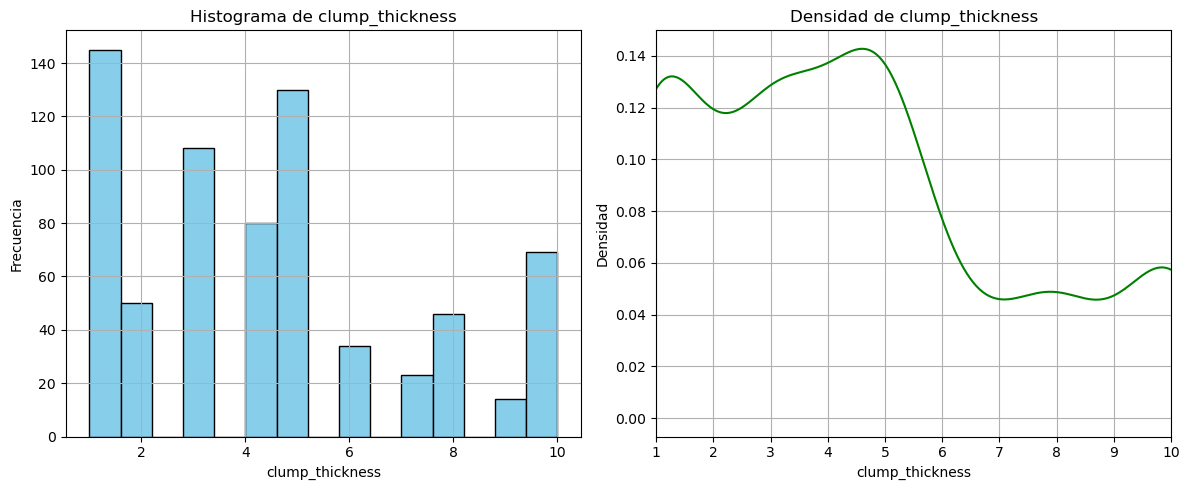

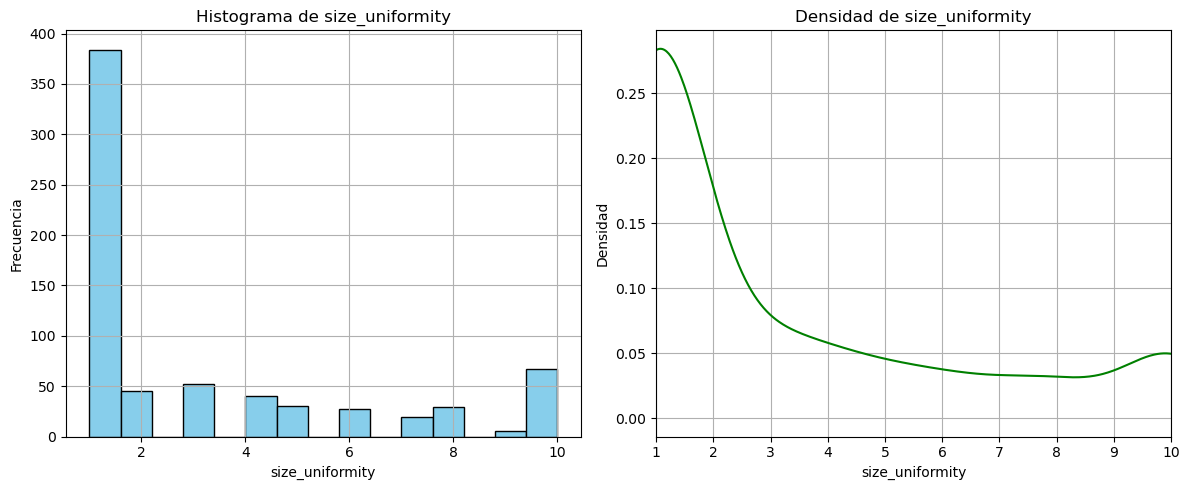

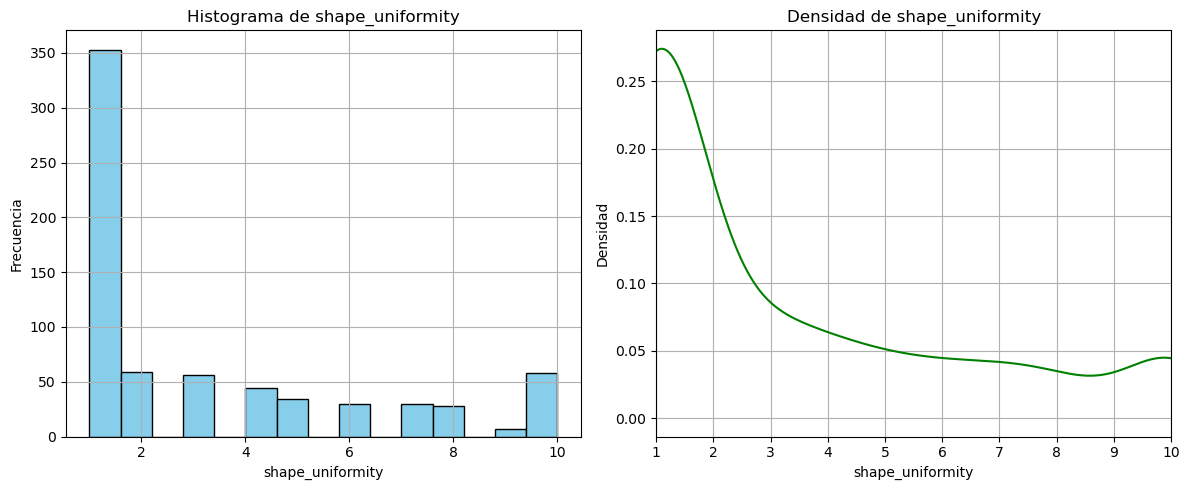

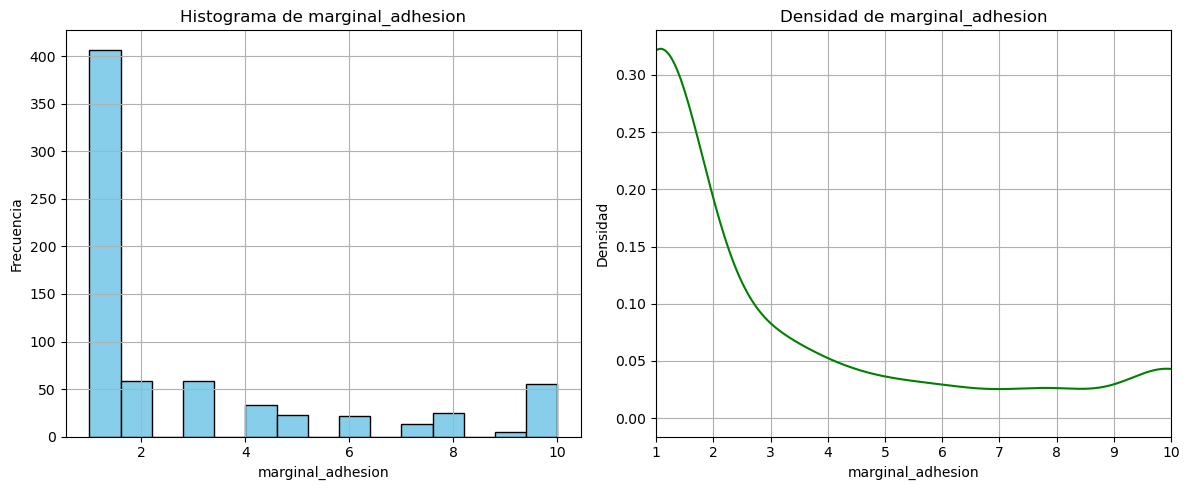

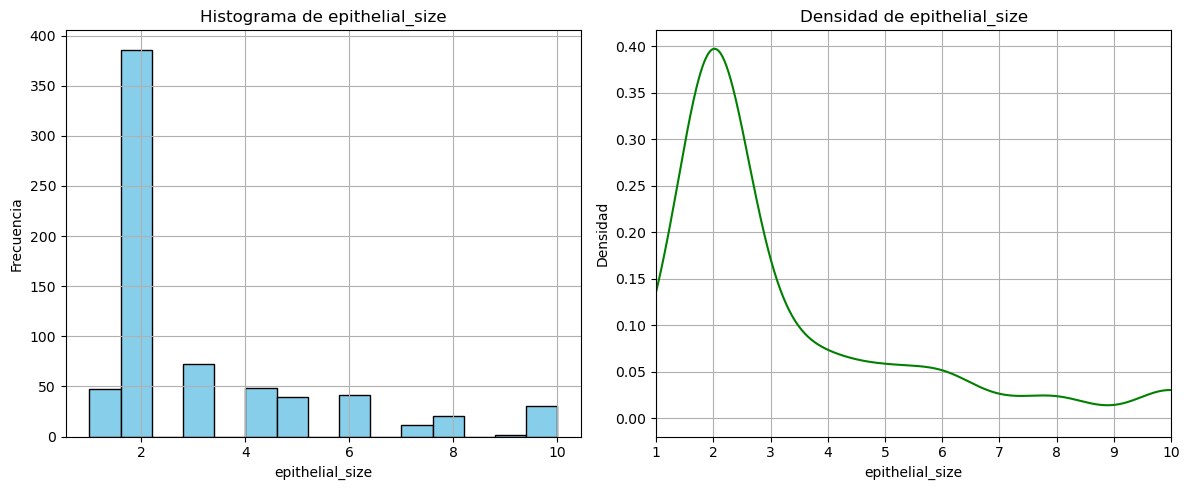

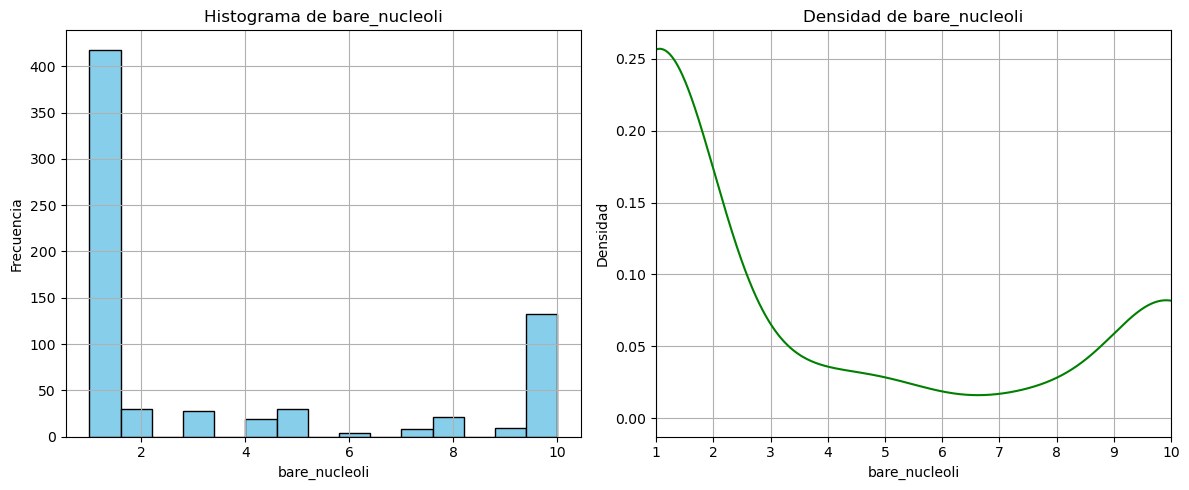

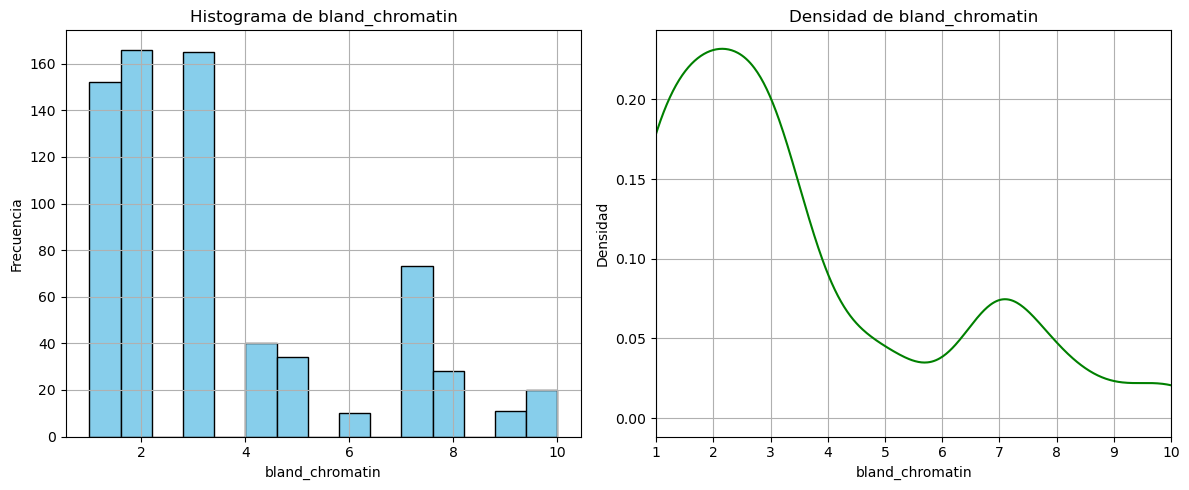

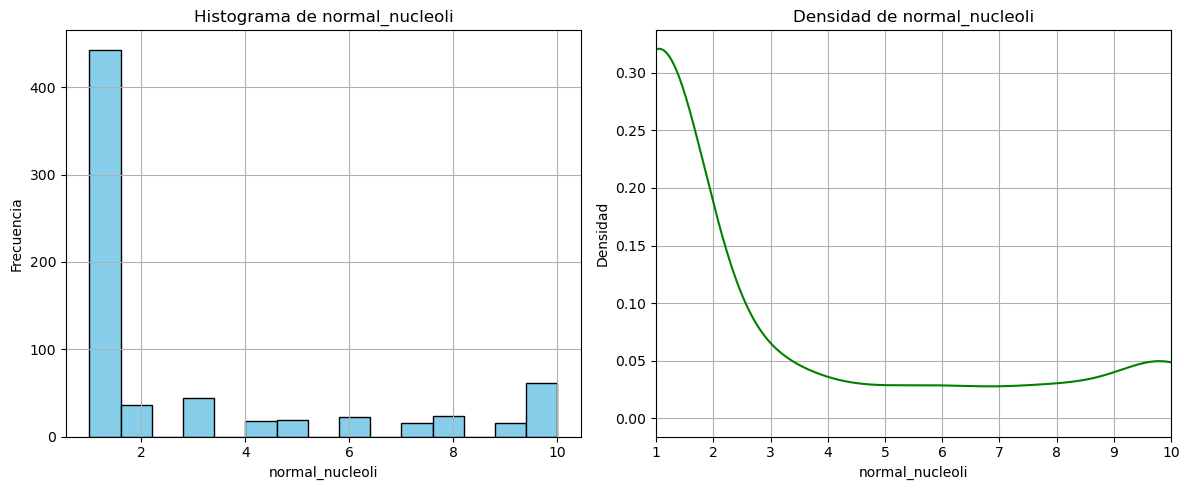

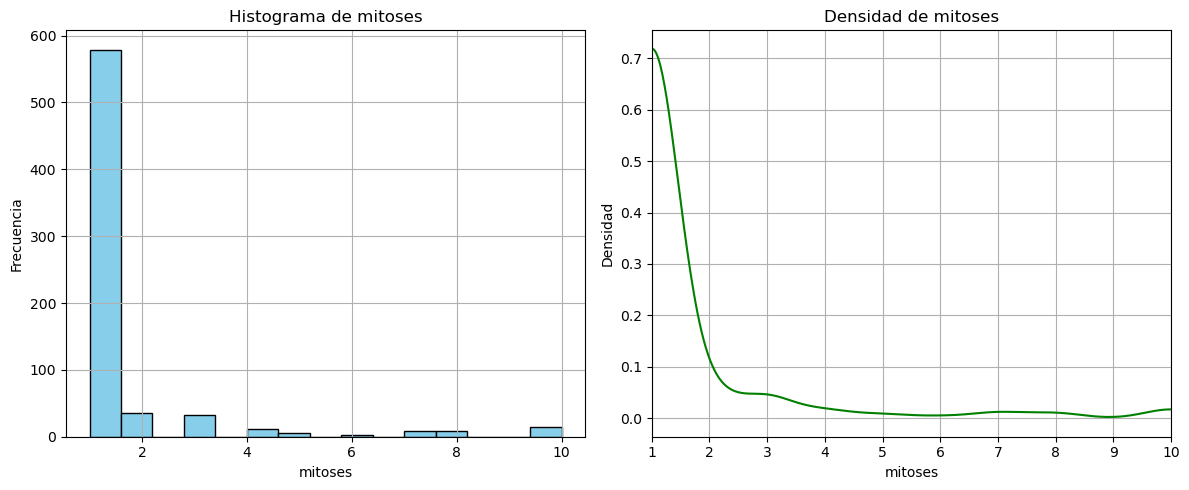

In [8]:
# Se mostrará una estructura de pares de gráficos (histograma y densidad) donde las filas corresponden a cada variable numérica
for col in data_numeric.columns: # Estructura de iteración sobre cada variable
    plt.figure(figsize=(12, 5)) # Tamaño de la gráfica (estará compuesta por 2 subgráficas)

    # Histograma
    plt.subplot(1, 2, 1) # Crea la primera subgráfica en una figura de 1 fila y 2 columnas (posición 1)
    plt.hist(data_numeric[col], bins=15, color='skyblue', edgecolor='black') # Genera el histograma segmentado en 15 bloques (bins)
    plt.title(f'Histograma de {col}') # Título del histograma
    plt.xlabel(col) # Etiqueta horizontal
    plt.ylabel('Frecuencia') # Etiqueta vertical
    plt.grid(True) # Muestra la grilla

    # Densidad
    plt.subplot(1, 2, 2) # Crea la segunda subgráfica en una figura de 1 fila y 2 columnas (posición 2)
    data_numeric[col].plot(kind='density', color='green') # Genera la curva suavizada de distribución de los datos
    plt.xlim(data_numeric[col].min(), data_numeric[col].max()) # Limitar el eje x al mínimo y máximo de la variable
    plt.title(f'Densidad de {col}') # Título del gráfico de densidad
    plt.xlabel(col) # Etiqueta horizontal
    plt.ylabel('Densidad') # Etiqueta vertical
    plt.grid(True) # Muestra la grilla

    plt.tight_layout() #  Se ajusta automáticamente los espacios entre gráficos para que no se sobrepongan
    plt.show()

### **Diagramas de Caja**

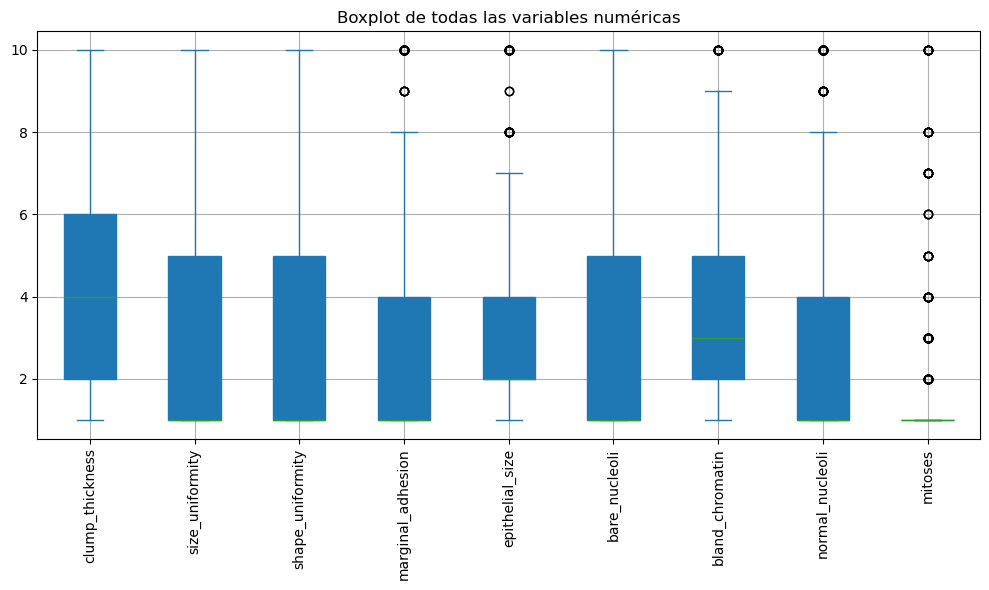

In [9]:
# Se mostrarán los diagramas de caja de todas las variables numéricas
data_numeric.plot(kind='box', patch_artist=True, grid=True, figsize=(10, 6)) # Se genera y da estilo al boxplot
plt.title('Boxplot de todas las variables numéricas') # Título de la gráfica
plt.xticks(rotation=90) # Rotación de las etiquetas del eje x
plt.tight_layout() # Se ajusta automáticamente los espacios de los elementos del gráfico
plt.show()

### **Diagramas de Dispersión**

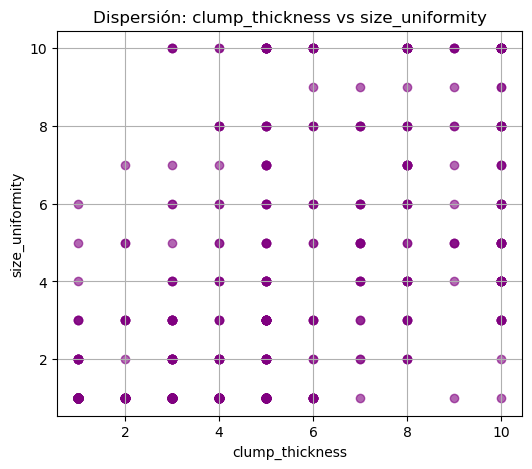

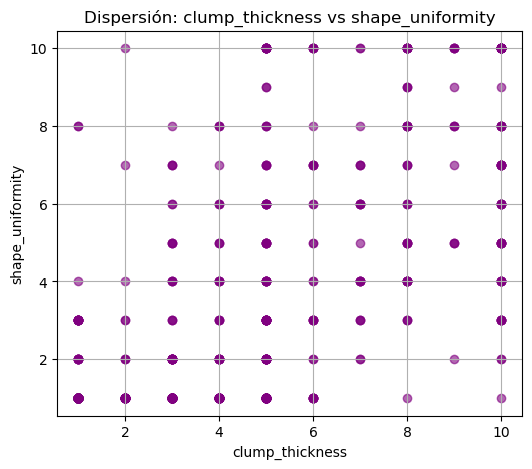

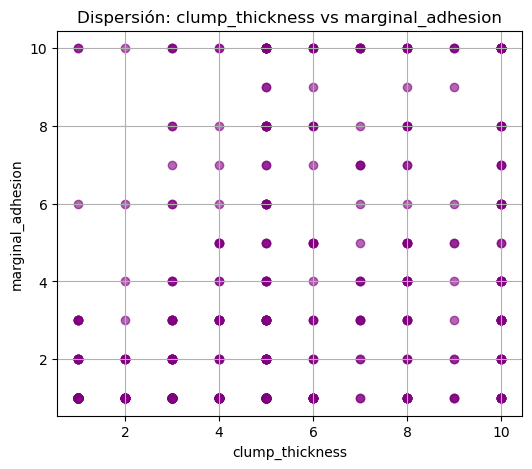

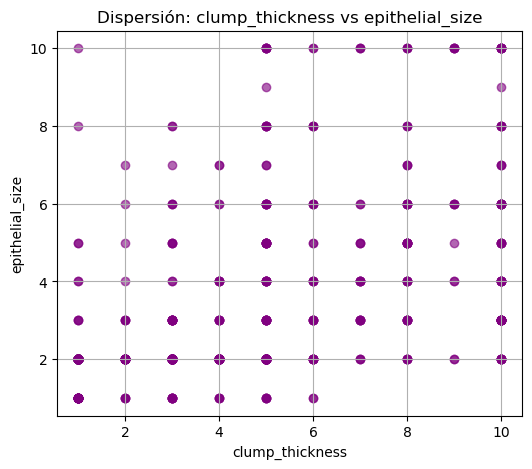

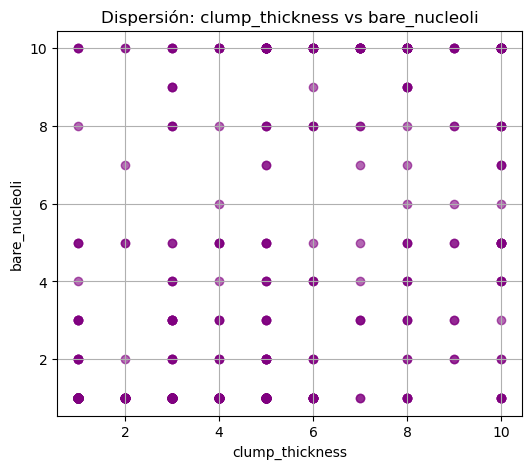

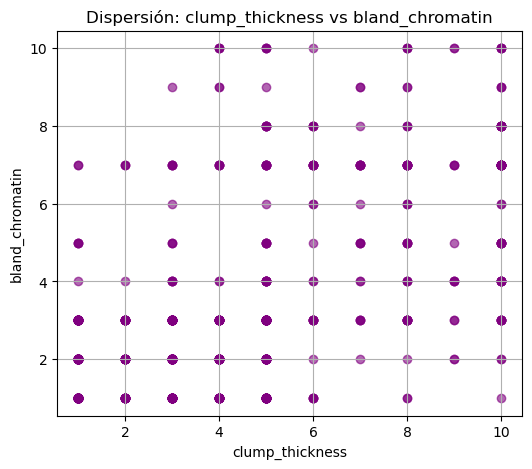

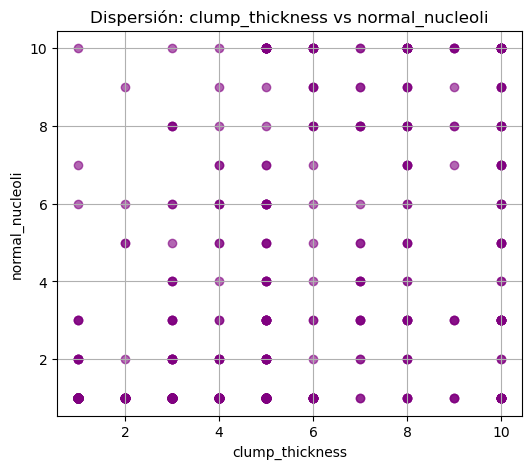

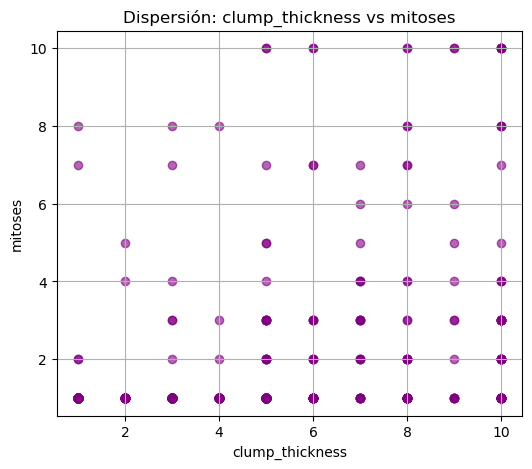

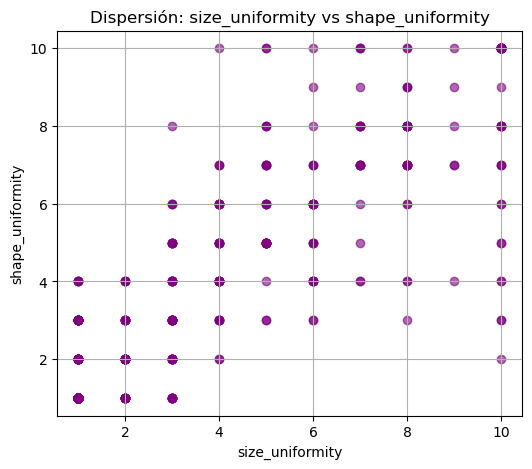

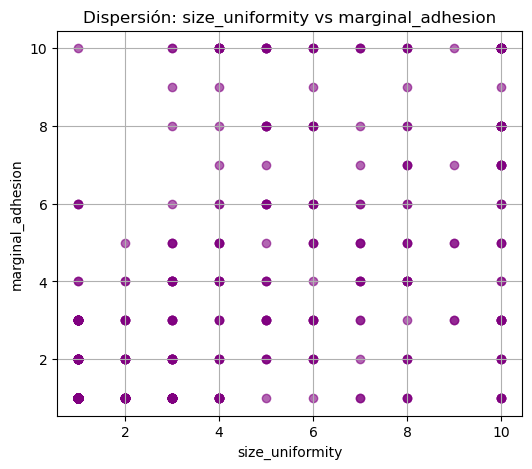

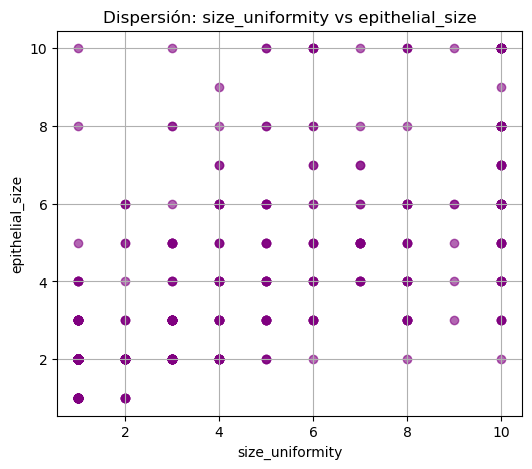

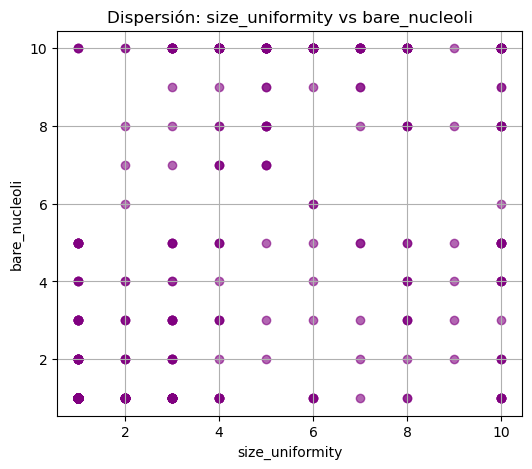

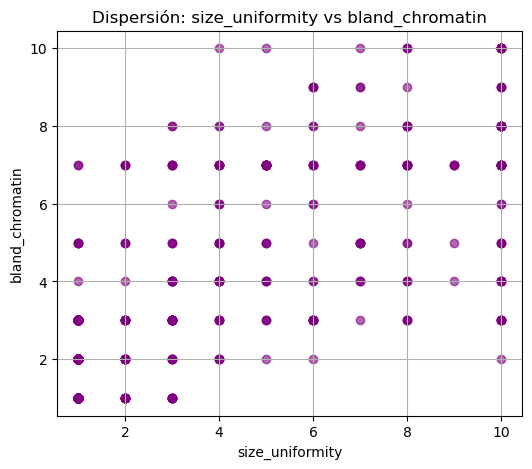

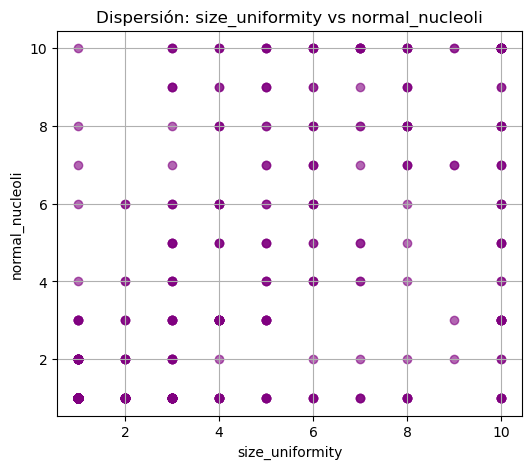

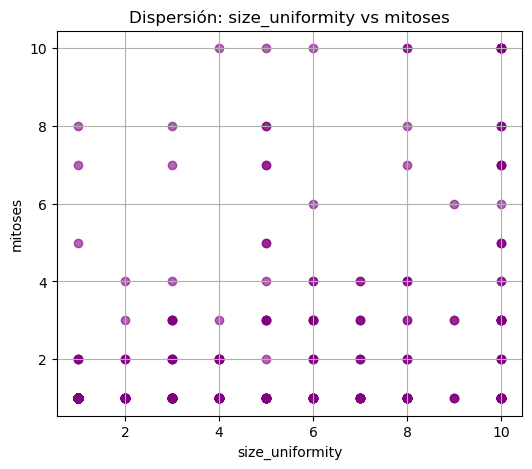

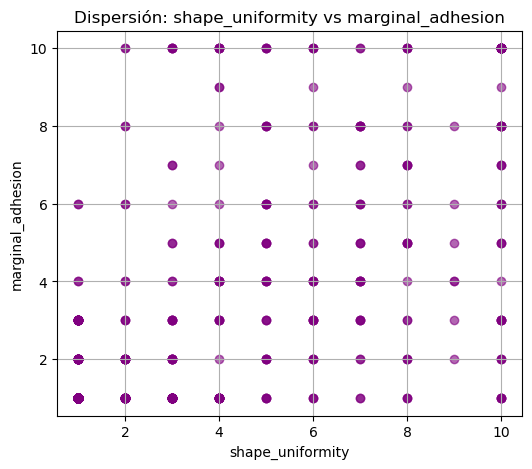

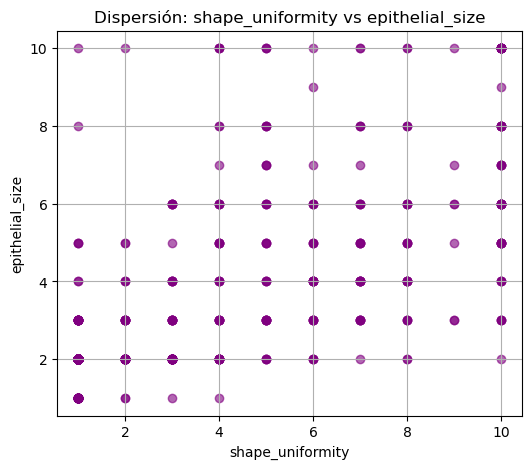

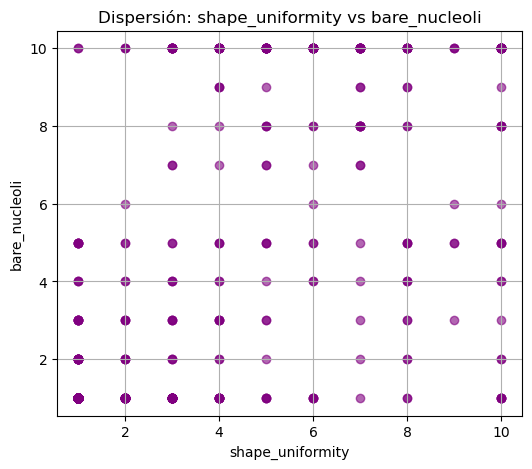

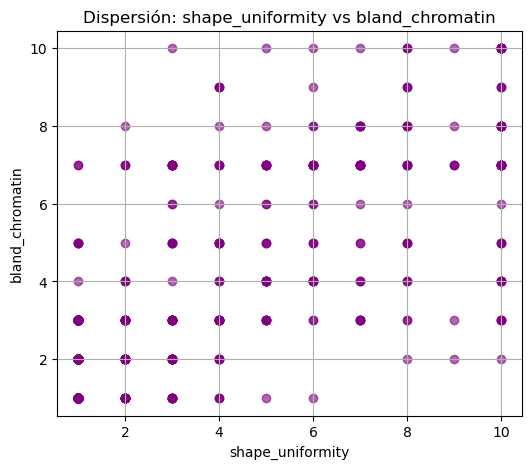

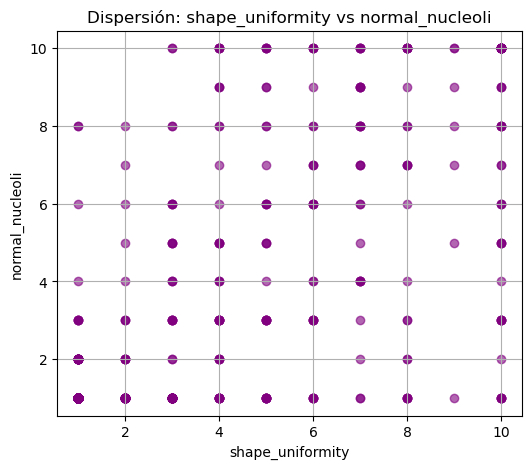

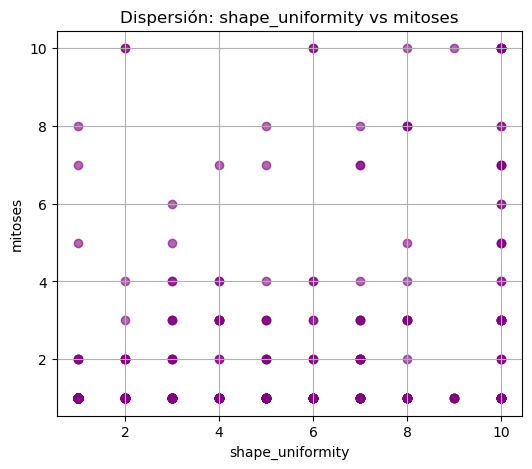

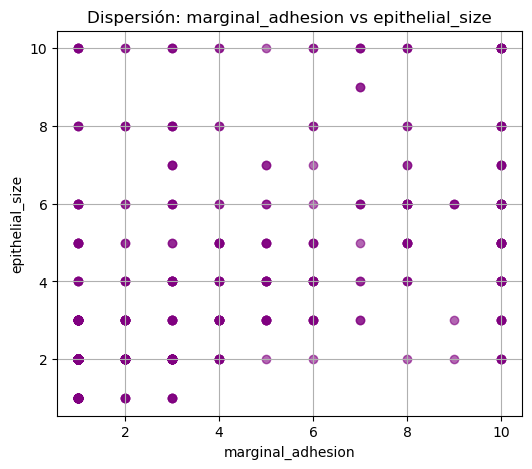

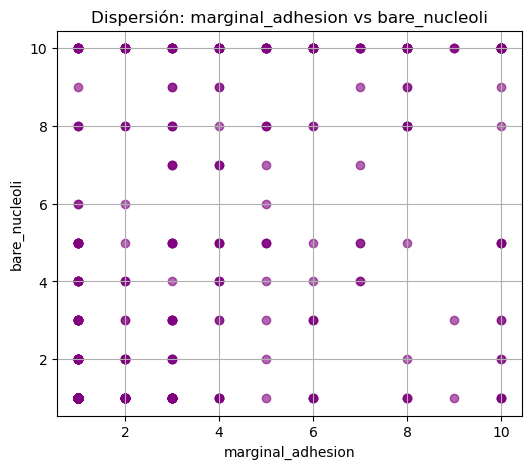

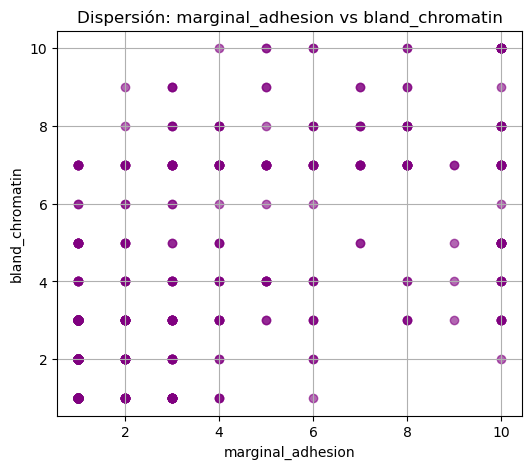

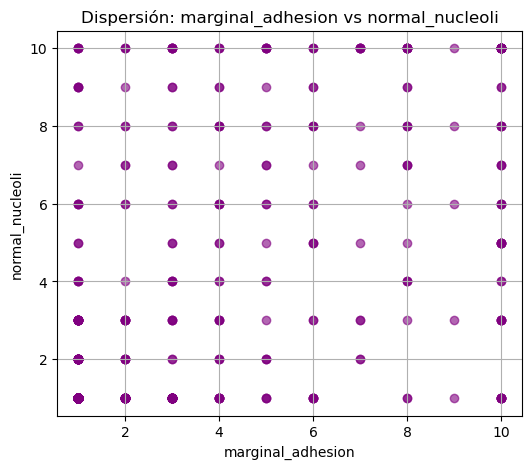

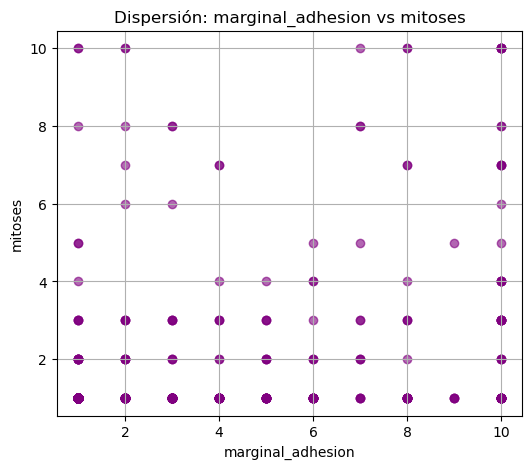

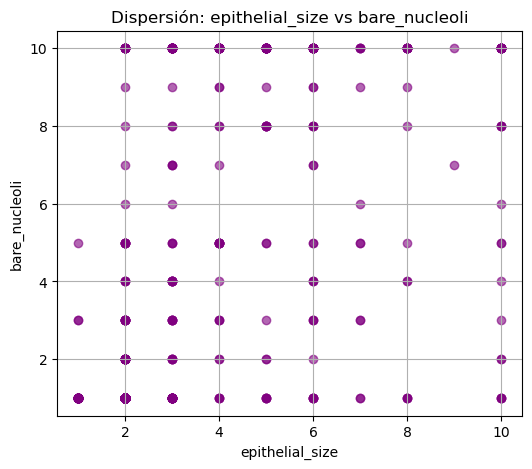

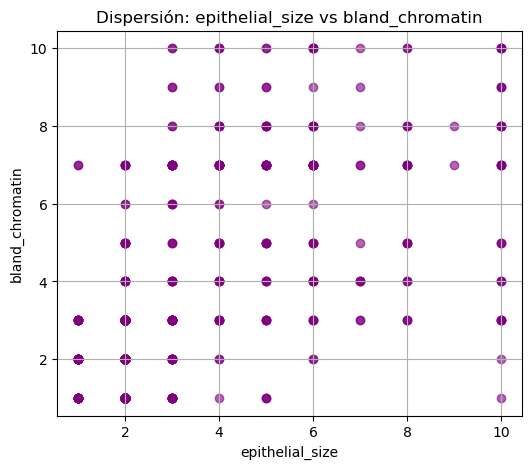

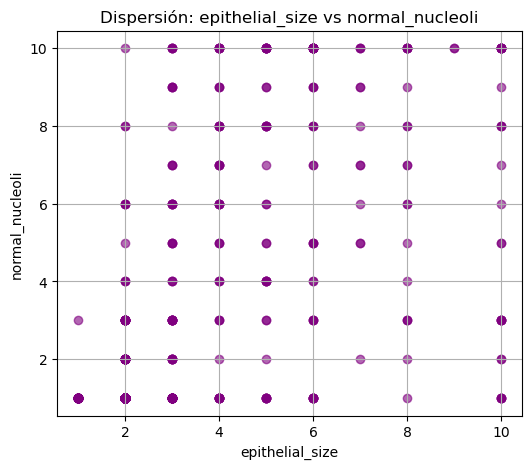

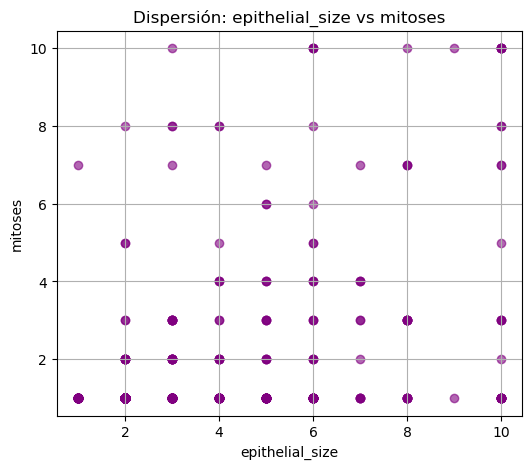

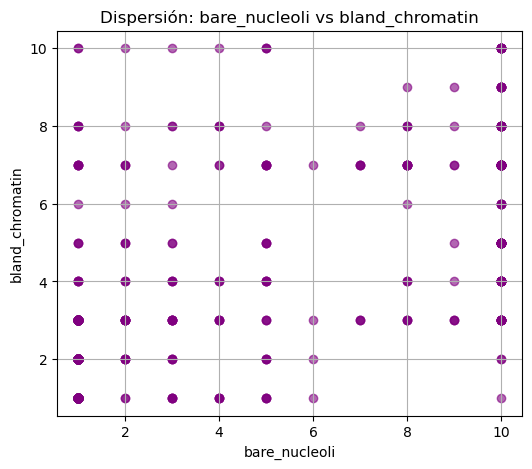

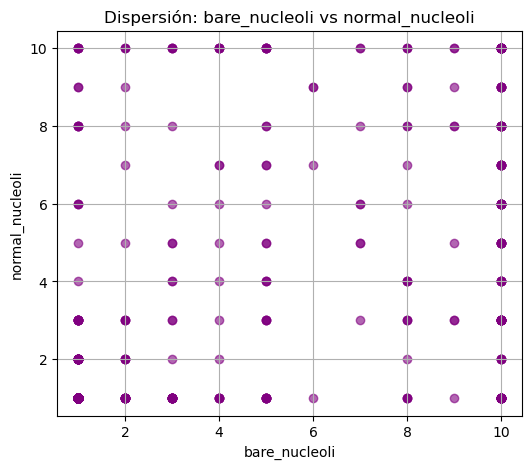

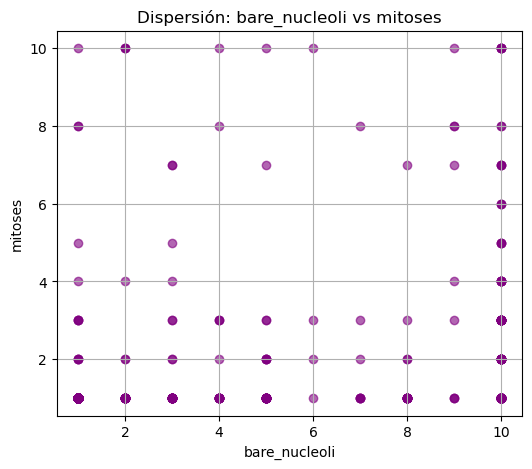

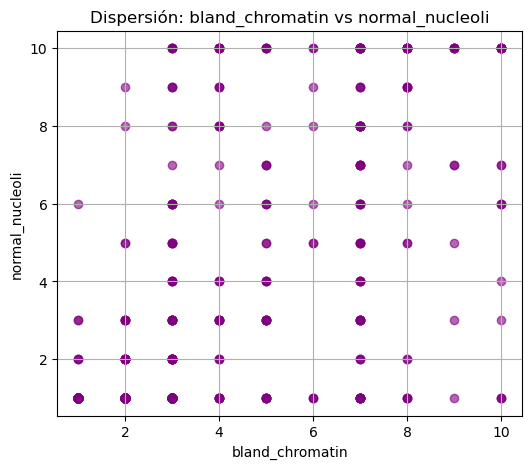

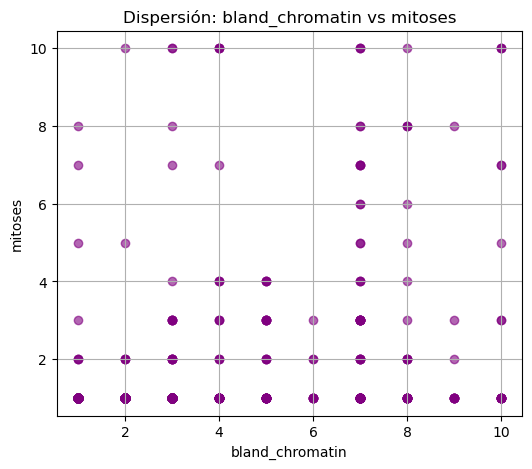

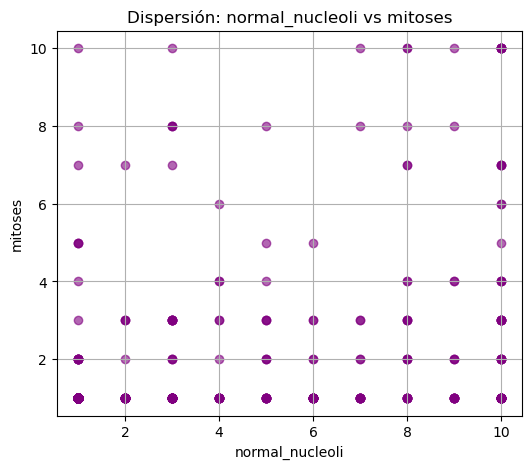

In [11]:
# Se generan scatter plots para todas las combinaciones de 2 variables

# Importación de librería
from itertools import combinations # Contiene funciones para crear combinaciones y permutaciones.

# Estructura de iteración para graficar pared de variables
for col1, col2 in combinations(data_numeric.columns, 2): # Recorre combinaciones de dos variables (col1 y col2) para graficarlas entre sí
    plt.figure(figsize=(6, 5)) # Tamaño de la figura
    plt.scatter(data_numeric[col1], data_numeric[col2], alpha=0.6, color='purple') # Se genera el diagrama de dispersión
    plt.title(f'Dispersión: {col1} vs {col2}') # Título de la figura
    plt.xlabel(col1) # Etiqueta horizontal
    plt.ylabel(col2) # Etiqueta vertical
    plt.grid(True) # Se muestra la grilla
    plt.show()

En las gráficas se observa que las nubes de puntos se encuentran bastante dispersas y no se identifican tendencias lineales.

## **PARTE C: Modelado**

Se genera un modelo k-NN para clasificar celulas benignas o malignas

In [12]:
# Se importan las librerías
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

In [13]:
# Se determina la variable objetivo y las variables predictoras
X = data_numeric # Variables numéricas predictoras
y = data['class'] # Variable objetivo categórica

# Se divide la data aleatoriamente en el 80% para el entrenamiento y 20% para la evaluación
# Se asigna un número semilla para la reproducibilidad (random_state)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Se genera el modelo k-NN considerando los 5 vecinos más cercanos
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train) # Se realiza el entrenamiento del modelo

# Se generan las predicciones del entrenamiento y la evaluación
y_pred_train = knn.predict(X_train)
y_pred_test = knn.predict(X_test)

# Se determina 
accuracy_train = accuracy_score(y_train, y_pred_train)
accuracy_test = accuracy_score(y_test, y_pred_test)

print(f'Precisión en entrenamiento: {accuracy_train:.2f}')
print(f'Precisión en prueba: {accuracy_test:.2f}')


In [ ]:
  # Puedes ajustar el valor de k
knn.fit(X_train, y_train)

In [ ]:
accuracy_train = accuracy_score(y_train, y_pred_train)
accuracy_test = accuracy_score(y_test, y_pred_test)

print(f'Precisión en entrenamiento: {accuracy_train:.2f}')
print(f'Precisión en prueba: {accuracy_test:.2f}')